In [67]:
import pandas as pd

print('loading your data')
df = pd.read_csv('/content/Train.csv')
print('succesfully loaded ')
df.shape

loading your data
succesfully loaded 


(14699, 14)

In [ ]:
df.isnull().sum()

In [68]:
X = df.drop(columns=['trip_distance_miles'])

In [69]:
y = df['trip_distance_miles']

In [70]:
X['pickup_datetime'] = pd.to_datetime(X['pickup_datetime'])
X['dropoff_datetime'] = pd.to_datetime(X['dropoff_datetime'])
X['duration'] = (X['dropoff_datetime'] - X['pickup_datetime']).dt.total_seconds() / 60
X.drop(columns=['pickup_datetime', 'dropoff_datetime'], inplace=True)

/tmp/ipykernel_6789/3962272241.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['pickup_datetime'] = pd.to_datetime(X['pickup_datetime'])
/tmp/ipykernel_6789/3962272241.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['dropoff_datetime'] = pd.to_datetime(X['dropoff_datetime'])


In [71]:
X.drop(columns=['tolls_amount'], inplace=True)

In [72]:
X[X['dropoff_borough'] != X['pickup_borough']]

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,passenger_count,traffic_congestion_level,pickup_borough,dropoff_borough,tip_amount,fare_estimate,duration
2,40.658970,-74.179122,40.628631,-74.180385,1,low,Other,Staten Island,2.36,20.22,8.0
11,40.691233,-73.929193,40.673138,-73.951614,1,high,Brooklyn,Other,2.74,17.30,14.0
14,40.789484,-73.929547,40.788293,-73.964584,2,medium,Manhattan,Other,2.05,23.66,11.0
29,40.644159,-74.243764,40.680742,-74.262023,1,high,Staten Island,Other,1.55,39.96,44.0
31,40.643993,-74.115996,40.532890,-74.081360,1,high,Staten Island,Other,6.34,77.18,53.0
...,...,...,...,...,...,...,...,...,...,...,...
14685,40.623290,-73.946388,40.635624,-73.997491,1,low,Brooklyn,Other,5.74,27.40,11.0
14686,40.750145,-73.986616,40.760606,-73.940001,3,high,Other,Manhattan,0.00,33.58,22.0
14687,40.687404,-73.876387,40.707341,-73.885509,2,high,Brooklyn,Manhattan,7.02,27.59,12.0
14689,40.894296,-73.942491,40.887344,-73.973090,1,high,Other,Bronx,4.82,34.43,12.0


In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

In [81]:
from sklearn.metrics import mean_squared_error ,r2_score ,mean_absolute_error ,accuracy_score

In [75]:
X

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,passenger_count,traffic_congestion_level,pickup_borough,dropoff_borough,tip_amount,fare_estimate,duration
0,40.690045,-74.239699,40.704018,-74.214368,2,high,Other,Other,0.14,18.40,13.0
1,40.763224,-74.053604,40.759277,-74.066002,1,medium,Other,Other,1.36,9.99,4.0
2,40.658970,-74.179122,40.628631,-74.180385,1,low,Other,Staten Island,2.36,20.22,8.0
3,40.696980,-73.773970,40.670444,-73.838194,2,medium,Brooklyn,Brooklyn,3.80,29.73,19.0
4,40.580638,-73.788101,40.594286,-73.780625,3,low,Brooklyn,Brooklyn,2.68,11.05,4.0
...,...,...,...,...,...,...,...,...,...,...,...
14694,40.818300,-74.037218,40.823860,-74.005730,4,medium,Bronx,Bronx,1.19,14.59,11.0
14695,40.913272,-74.012950,40.936902,-74.031666,1,high,Bronx,Bronx,3.58,20.40,17.0
14696,40.808487,-74.072608,40.804565,-74.033420,2,medium,Bronx,Bronx,2.69,14.64,9.0
14697,40.605883,-73.902029,40.693266,-73.843018,3,high,Brooklyn,Brooklyn,13.61,60.69,53.0


In [76]:
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.pipeline import make_pipeline

enc = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
col_ohe = ['pickup_borough','dropoff_borough']
encoded_features = enc.fit_transform(X[col_ohe])
encoded_df = pd.DataFrame(encoded_features, columns=enc.get_feature_names_out(col_ohe), index=X.index)
X = pd.concat([X.drop(columns=col_ohe), encoded_df], axis=1)

# Ordinal Encoding for 'traffic_congestion_level'
ord = OrdinalEncoder(categories=[['low', 'medium', 'high']]) # Define order based on typical understanding
X['traffic_congestion_level'] = ord.fit_transform(X[['traffic_congestion_level']])

X

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,passenger_count,traffic_congestion_level,tip_amount,fare_estimate,duration,pickup_borough_Brooklyn,pickup_borough_Manhattan,pickup_borough_Other,pickup_borough_Staten Island,dropoff_borough_Brooklyn,dropoff_borough_Manhattan,dropoff_borough_Other,dropoff_borough_Staten Island
0,40.690045,-74.239699,40.704018,-74.214368,2,2.0,0.14,18.40,13.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,40.763224,-74.053604,40.759277,-74.066002,1,1.0,1.36,9.99,4.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,40.658970,-74.179122,40.628631,-74.180385,1,0.0,2.36,20.22,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,40.696980,-73.773970,40.670444,-73.838194,2,1.0,3.80,29.73,19.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,40.580638,-73.788101,40.594286,-73.780625,3,0.0,2.68,11.05,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14694,40.818300,-74.037218,40.823860,-74.005730,4,1.0,1.19,14.59,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14695,40.913272,-74.012950,40.936902,-74.031666,1,2.0,3.58,20.40,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14696,40.808487,-74.072608,40.804565,-74.033420,2,1.0,2.69,14.64,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14697,40.605883,-73.902029,40.693266,-73.843018,3,2.0,13.61,60.69,53.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
clf1 = LinearRegression()
clf1.fit(X_train,y_train)
y_pred = clf1.predict(X_test)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

20.979360347370832
0.6679072160804205
3.7709891153149


In [82]:
clf2 = DecisionTreeRegressor(random_state=42)
clf2.fit(X_train,y_train)
y_pred_dt = clf2.predict(X_test)
print("Decision Tree Regressor Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test,y_pred_dt)}")
print(f"R2 Score: {r2_score(y_test,y_pred_dt)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test,y_pred_dt)}")

Decision Tree Regressor Metrics:
Mean Squared Error: 6.1817417672312915
R2 Score: 0.9021461189016159
Mean Absolute Error: 1.8056429251700683


In [83]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
clf_ridge = Ridge(random_state=42)
clf_ridge.fit(X_train, y_train)
y_pred_ridge = clf_ridge.predict(X_test)
print("\nRidge Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_ridge)}")
print(f"R2 Score: {r2_score(y_test, y_pred_ridge)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_ridge)}")

# Lasso Regression
clf_lasso = Lasso(random_state=42)
clf_lasso.fit(X_train, y_train)
y_pred_lasso = clf_lasso.predict(X_test)
print("\nLasso Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lasso)}")
print(f"R2 Score: {r2_score(y_test, y_pred_lasso)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_lasso)}")


Ridge Regression Metrics:
Mean Squared Error: 20.975262367779635
R2 Score: 0.6679720850482229
Mean Absolute Error: 3.7708264911558933

Lasso Regression Metrics:
Mean Squared Error: 22.624792747732823
R2 Score: 0.6418608439537237
Mean Absolute Error: 3.953661852700975


In [84]:
clf_svr = SVR()
clf_svr.fit(X_train, y_train)
y_pred_svr = clf_svr.predict(X_test)
print("\nSVR Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_svr)}")
print(f"R2 Score: {r2_score(y_test, y_pred_svr)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_svr)}")


SVR Metrics:
Mean Squared Error: 11.327324574138602
R2 Score: 0.8206941160311507
Mean Absolute Error: 2.5973415222503413


In [85]:
clf_rf = RandomForestRegressor(random_state=42)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)
print("\nRandom Forest Regressor Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rf)}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_rf)}")


Random Forest Regressor Metrics:
Mean Squared Error: 3.13047594387893
R2 Score: 0.9504461311506901
Mean Absolute Error: 1.3170424972789119


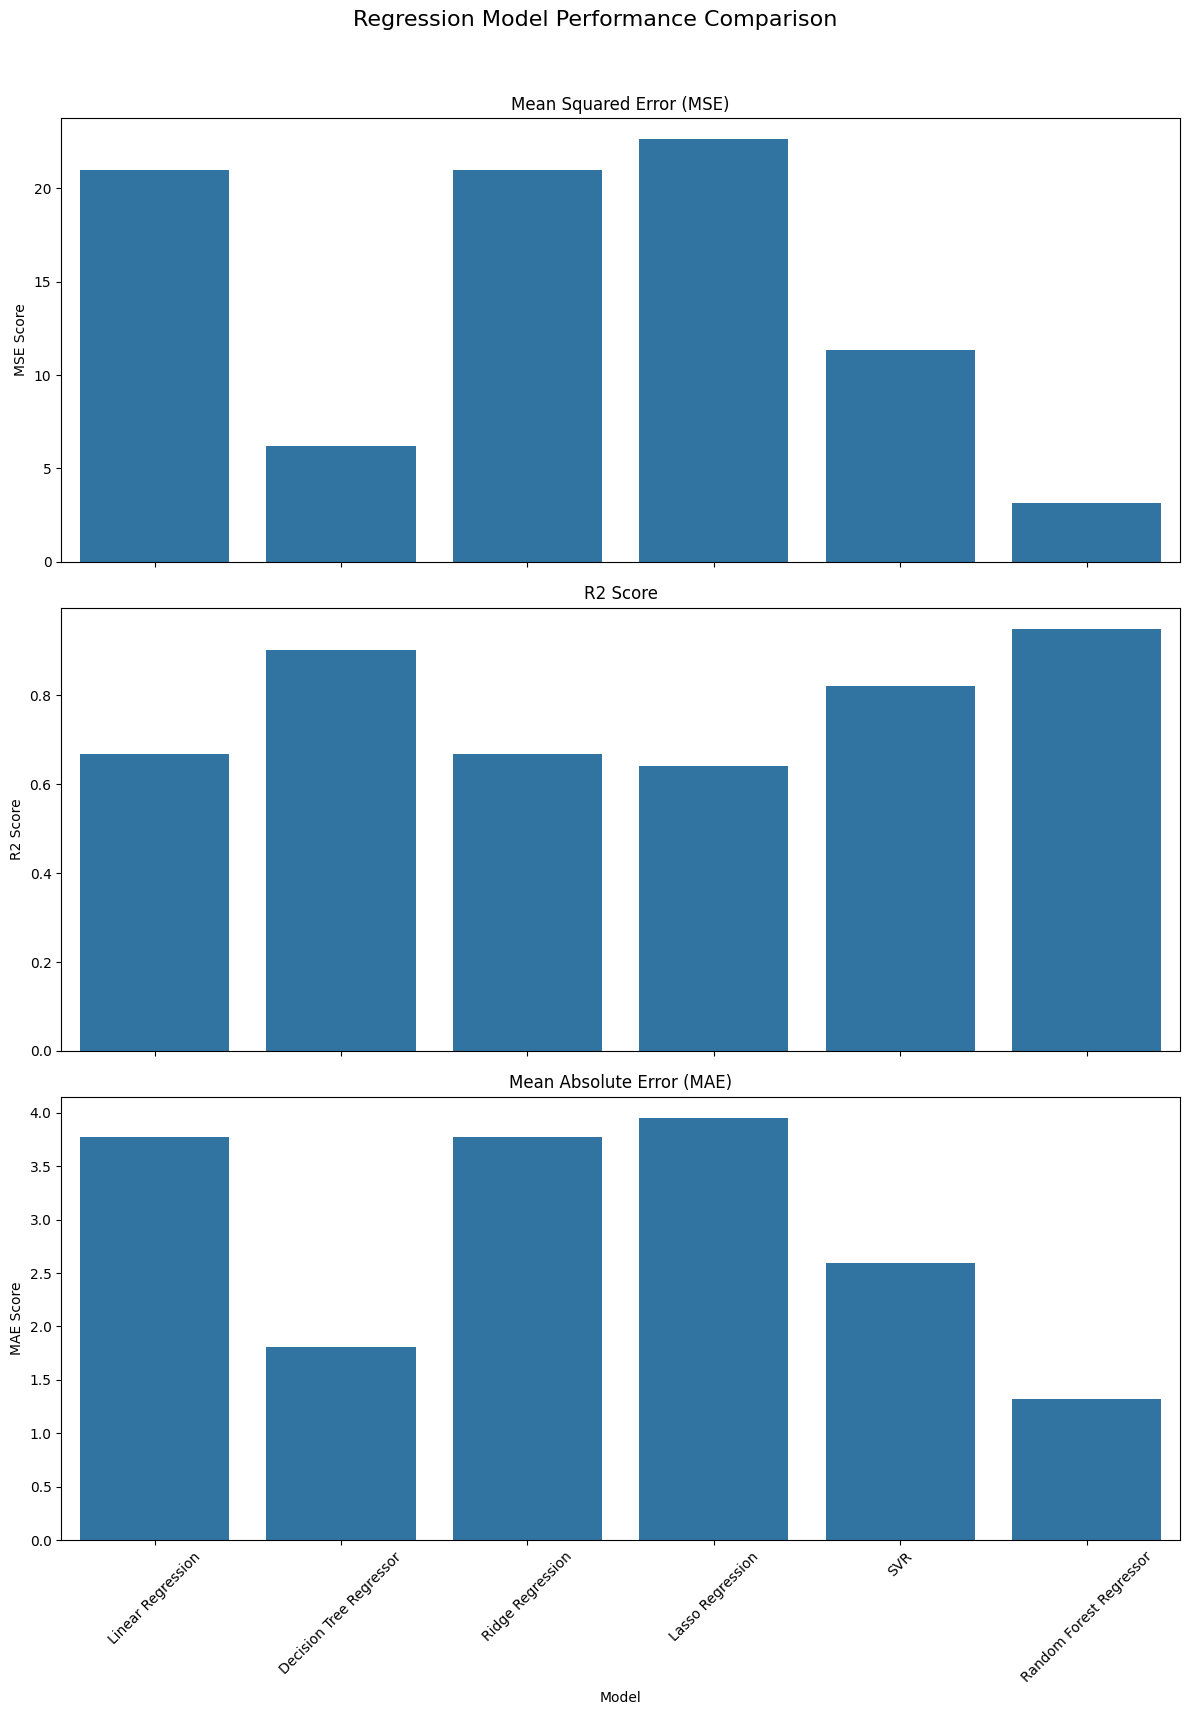

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the metrics for each model
model_names = [
    'Linear Regression',
    'Decision Tree Regressor',
    'Ridge Regression',
    'Lasso Regression',
    'SVR',
    'Random Forest Regressor'
]

mse_scores = [
    mean_squared_error(y_test, y_pred),
    mean_squared_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_ridge),
    mean_squared_error(y_test, y_pred_lasso),
    mean_squared_error(y_test, y_pred_svr),
    mean_squared_error(y_test, y_pred_rf)
]

r2_scores = [
    r2_score(y_test, y_pred),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso),
    r2_score(y_test, y_pred_svr),
    r2_score(y_test, y_pred_rf)
]

mae_scores = [
    mean_absolute_error(y_test, y_pred),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_ridge),
    mean_absolute_error(y_test, y_pred_lasso),
    mean_absolute_error(y_test, y_pred_svr),
    mean_absolute_error(y_test, y_pred_rf)
]

# Create a DataFrame for easy plotting
metrics_df = pd.DataFrame({
    'Model': model_names,
    'MSE': mse_scores,
    'R2 Score': r2_scores,
    'MAE': mae_scores
})

metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create subplots for each metric
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
fig.suptitle('Regression Model Performance Comparison', fontsize=16)

# Plot MSE
sns.barplot(x='Model', y='Score', data=metrics_df_melted[metrics_df_melted['Metric'] == 'MSE'], ax=axes[0])
axes[0].set_title('Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE Score')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Plot R2 Score
sns.barplot(x='Model', y='Score', data=metrics_df_melted[metrics_df_melted['Metric'] == 'R2 Score'], ax=axes[1])
axes[1].set_title('R2 Score')
axes[1].set_ylabel('R2 Score')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Plot MAE
sns.barplot(x='Model', y='Score', data=metrics_df_melted[metrics_df_melted['Metric'] == 'MAE'], ax=axes[2])
axes[2].set_title('Mean Absolute Error (MAE)')
axes[2].set_ylabel('MAE Score')
axes[2].set_xlabel('Model')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [88]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import RandomForestRegressor
import joblib

# 1. Define initial feature engineering function (outside pipeline as it's dataset-specific)
#    This function will be applied to X_for_pipeline_training before it enters the main pipeline
def apply_initial_feature_engineering(X):
    X_copy = X.copy()
    X_copy['pickup_datetime'] = pd.to_datetime(X_copy['pickup_datetime'], format='%m/%d/%y %H:%M')
    X_copy['dropoff_datetime'] = pd.to_datetime(X_copy['dropoff_datetime'], format='%m/%d/%y %H:%M')
    X_copy['duration'] = (X_copy['dropoff_datetime'] - X_copy['pickup_datetime']).dt.total_seconds() / 60
    X_copy.drop(columns=['pickup_datetime', 'dropoff_datetime', 'tolls_amount'], inplace=True)
    return X_copy

# 2. Define a custom transformer to select specific columns from a DataFrame
class DataFrameColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.columns].copy()

# Define feature groups
numerical_features = [
    'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude',
    'passenger_count', 'tip_amount', 'fare_estimate', 'duration'
]
categorical_features = ['pickup_borough', 'dropoff_borough']
ordinal_features = ['traffic_congestion_level']
ordinal_categories = [['low', 'medium', 'high']] # Order based on prior notebook steps

# 3. Create FeatureUnion to combine different preprocessing branches
feature_preprocessing_union = FeatureUnion(transformer_list=[
    ('numerical_features_pipe', Pipeline(steps=[
        ('selector', DataFrameColumnSelector(columns=numerical_features))
        # No explicit transformer needed for passthrough, the selector output will be directly used.
    ])),
    ('categorical_features_pipe', Pipeline(steps=[
        ('selector', DataFrameColumnSelector(columns=categorical_features)),
        ('onehot_encode', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ])),
    ('ordinal_features_pipe', Pipeline(steps=[
        ('selector', DataFrameColumnSelector(columns=ordinal_features)),
        ('ordinal_encode', OrdinalEncoder(categories=ordinal_categories))
    ]))
])

# 4. Create the full pipeline with FeatureUnion as the preprocessing step and RandomForestRegressor
full_pipeline = Pipeline(steps=[
    ('features', feature_preprocessing_union),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Re-load data to create the base for the pipeline
df_raw = pd.read_csv('/content/Train.csv')
y_for_pipeline_training = df_raw['trip_distance_miles']
X_for_pipeline_training = df_raw.drop(columns=['trip_distance_miles'])

print("Applying initial feature engineering for pipeline input...")
X_for_pipeline_training = apply_initial_feature_engineering(X_for_pipeline_training)
print("Initial feature engineering complete.")

# Fit the pipeline on the prepared full dataset
print("Fitting the complete Random Forest pipeline...")
full_pipeline.fit(X_for_pipeline_training, y_for_pipeline_training)
print("Pipeline fitted successfully.")

# Export the trained pipeline as 'model.pkl'
joblib.dump(full_pipeline, 'model.pkl')
print("Trained pipeline exported as 'model.pkl'.")

# Export the final preprocessed features (X) from the current notebook state as 'data.pkl'
# This X is the one after all encoding and transformations in the notebook.
joblib.dump(X, 'data.pkl')
print("Preprocessed features (X) exported as 'data.pkl'.")

print("\nModel and data export complete.")

Applying initial feature engineering for pipeline input...
Initial feature engineering complete.
Fitting the complete Random Forest pipeline...
Pipeline fitted successfully.
Trained pipeline exported as 'model.pkl'.
Preprocessed features (X) exported as 'data.pkl'.

Model and data export complete.


In [89]:
import gradio as gr
import joblib
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

# Re-define the initial feature engineering function (needed for the prediction function)
def apply_initial_feature_engineering(X):
    X_copy = X.copy()
    X_copy['pickup_datetime'] = pd.to_datetime(X_copy['pickup_datetime'], format='%m/%d/%y %H:%M')
    X_copy['dropoff_datetime'] = pd.to_datetime(X_copy['dropoff_datetime'], format='%m/%d/%y %H:%M')
    X_copy['duration'] = (X_copy['dropoff_datetime'] - X_copy['pickup_datetime']).dt.total_seconds() / 60
    X_copy.drop(columns=['pickup_datetime', 'dropoff_datetime', 'tolls_amount'], inplace=True)
    return X_copy

# Re-define the custom DataFrameColumnSelector (needed because it's part of the pipeline's structure)
class DataFrameColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.columns].copy()

# Load the trained pipeline
try:
    loaded_pipeline = joblib.load('model.pkl')
    print("Model 'model.pkl' loaded successfully.")
except FileNotFoundError:
    print("Error: 'model.pkl' not found. Please ensure the model is trained and exported.")
    loaded_pipeline = None

# Load the raw data to get unique categorical values for dropdowns
df_raw_for_choices = pd.read_csv('/content/Train.csv')
pickup_borough_choices = df_raw_for_choices['pickup_borough'].unique().tolist()
dropoff_borough_choices = df_raw_for_choices['dropoff_borough'].unique().tolist()
traffic_congestion_level_choices = ['low', 'medium', 'high'] # As defined in OrdinalEncoder

def predict_trip_distance(
    pickup_datetime_str, dropoff_datetime_str, pickup_latitude, pickup_longitude,
    dropoff_latitude, dropoff_longitude, passenger_count, tolls_amount,
    traffic_congestion_level, pickup_borough, dropoff_borough, tip_amount, fare_estimate
):
    if loaded_pipeline is None:
        return "Model not loaded. Cannot make prediction."

    # Create a DataFrame from the inputs, matching the original raw data structure
    input_data = pd.DataFrame({
        'pickup_datetime': [pickup_datetime_str],
        'dropoff_datetime': [dropoff_datetime_str],
        'pickup_latitude': [pickup_latitude],
        'pickup_longitude': [pickup_longitude],
        'dropoff_latitude': [dropoff_latitude],
        'dropoff_longitude': [dropoff_longitude],
        'passenger_count': [passenger_count],
        'tolls_amount': [tolls_amount],
        'traffic_congestion_level': [traffic_congestion_level],
        'pickup_borough': [pickup_borough],
        'dropoff_borough': [dropoff_borough],
        'tip_amount': [tip_amount],
        'fare_estimate': [fare_estimate]
    })

    # Apply the initial feature engineering step
    processed_input_data = apply_initial_feature_engineering(input_data.copy())

    # Predict using the loaded pipeline
    prediction = loaded_pipeline.predict(processed_input_data)[0]
    return f"{prediction:.2f} miles"

# Gradio Interface
if loaded_pipeline is not None:
    inputs = [
        gr.Textbox(label="Pickup Datetime (e.g., MM/DD/YY HH:MM)", value="03/22/24 09:10"),
        gr.Textbox(label="Dropoff Datetime (e.g., MM/DD/YY HH:MM)", value="03/22/24 09:23"),
        gr.Number(label="Pickup Latitude", value=40.69),
        gr.Number(label="Pickup Longitude", value=-74.23),
        gr.Number(label="Dropoff Latitude", value=40.70),
        gr.Number(label="Dropoff Longitude", value=-74.21),
        gr.Slider(1, 6, step=1, value=1, label="Passenger Count"),
        gr.Number(label="Tolls Amount", value=0.0),
        gr.Dropdown(traffic_congestion_level_choices, label="Traffic Congestion Level", value='high'),
        gr.Dropdown(pickup_borough_choices, label="Pickup Borough", value='Other'),
        gr.Dropdown(dropoff_borough_choices, label="Dropoff Borough", value='Other'),
        gr.Number(label="Tip Amount", value=0.14),
        gr.Number(label="Fare Estimate", value=18.40)
    ]

    outputs = gr.Textbox(label="Predicted Trip Distance")

    gr.Interface(
        fn=predict_trip_distance,
        inputs=inputs,
        outputs=outputs,
        title="Trip Distance Prediction App",
        description="Enter trip details to predict the distance in miles."
    ).launch()
else:
    print("Gradio interface not launched due to missing model.")

Model 'model.pkl' loaded successfully.
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8f7dc2eee0a9362aac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
